<a href="https://colab.research.google.com/github/simomorphine/a-philosophical-attempt-to-build-the-mathematical-foundation-for-complex-reinforcement-learning/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> ⚠️ **Please note:** I’m still learning about this topic and exploring the mathematics behind it. 🧠📚
>
> 🧪 **The lab has also been generated with the help of DeepSeek.** 🤖
>
> 🔗 For now, we are **just making the connection exist** — connecting these ideas mathematically so that we have something concrete to investigate, test, and improve later.
>
> It doesn’t have to be perfect at this stage. The goal is to **put the mathematical machinery on the table** and see what it can do. 🔬📐
>
> 🚧 **This is an ongoing research exploration, not a finished result.**
>
> 🐇🐰🕳️ **We make the connection first. Then we follow the rabbit hole.** ❤️



# Section 1 — The Complex Regret

## 1.1 A regret trajectory is not a number

Take the simplest bandit: two Bernoulli arms, μ = (0.5, 0.4), horizon T = 100. Run Thompson, UCB1, ε-greedy, EXP3. Report R(T): you get four numbers. That's how every bandit paper compares algorithms, and it hides everything.

Consider two runs both ending at R(T) = 10. Run A paid 1 unit in the first 10 steps and 9 in the last 90 — learned fast, exploited poorly. Run B paid 9 early and 1 late — explored wastefully, converged. Same scalar, opposite behavior. And the scalar says nothing about *what the algorithm expects*: one that has paid 10 and expects 0 more is in a completely different state from one that has paid 0 and expects 10 more.

We want to keep these two things separate. Track regret already paid and regret still expected, at every step, as two coordinates of one object.

## 1.2 The two coordinates

Fix an instance ν with means μ_1..μ_K, μ* = max_a μ_a, horizon T. Let a_t be the arm pulled at t, H_t the history.

**Realized regret:**
  R(t) = Σ_{s=1}^t (μ* − μ_{a_s})

**Future regret:**
  F(t) = E[ R(T) − R(t) | H_t ]

**The regret trajectory:**
  z(t) = R(t) + i·F(t)

Real axis = past, imaginary axis = future. At t = 0: z(0) = i·E[R(T)], purely imaginary. At t = T: z(T) = R(T), purely real. How the path gets from one to the other is the algorithm.

## 1.3 The increment

  Δz(t) = ΔR(t) + i·ΔF(t)
  ΔR(t) = μ* − μ_{a_{t+1}}  (regret of the next pull)
  ΔF(t) = F(t+1) − F(t)     (revision of expected future regret)

Conversion angle: θ(t) = arg Δz(t).

Three facts fall out immediately:
1. **ΔR ≥ 0 always** — regret only accumulates, so Δz always points into the right half-plane.
2. **ΔF has no sign** — it can be negative (learned something useful) or positive (learned the problem is harder).
3. **θ measures efficiency** — θ = 0° is pure realized regret (taught nothing), θ = ±90° is pure belief revision (cost nothing).

## 1.4 The four algorithms, and how to compute F

We need F(t) for each. Thompson has an intrinsic posterior, so F is computed by Monte Carlo on its own posterior. For the frequentist algorithms (UCB, ε-greedy, EXP3) we impose a *reference* Beta posterior on the observed rewards, with the true means known — the "external observer" F. That distinction matters later; for Section 1 it just gives us four curves.

## 1.5 The picture

Four curves, all starting on the imaginary axis, all ending on the real axis, all moving only rightward. Thompson is the straightest and shortest, hugging the diagonal. ε-greedy is the flattest. UCB bulges above the diagonal. EXP3 is the noisiest. The dashed diagonal is the conservation line r + f = E[R(T)], which Section 2 will derive.




Saved section1_trajectories.png


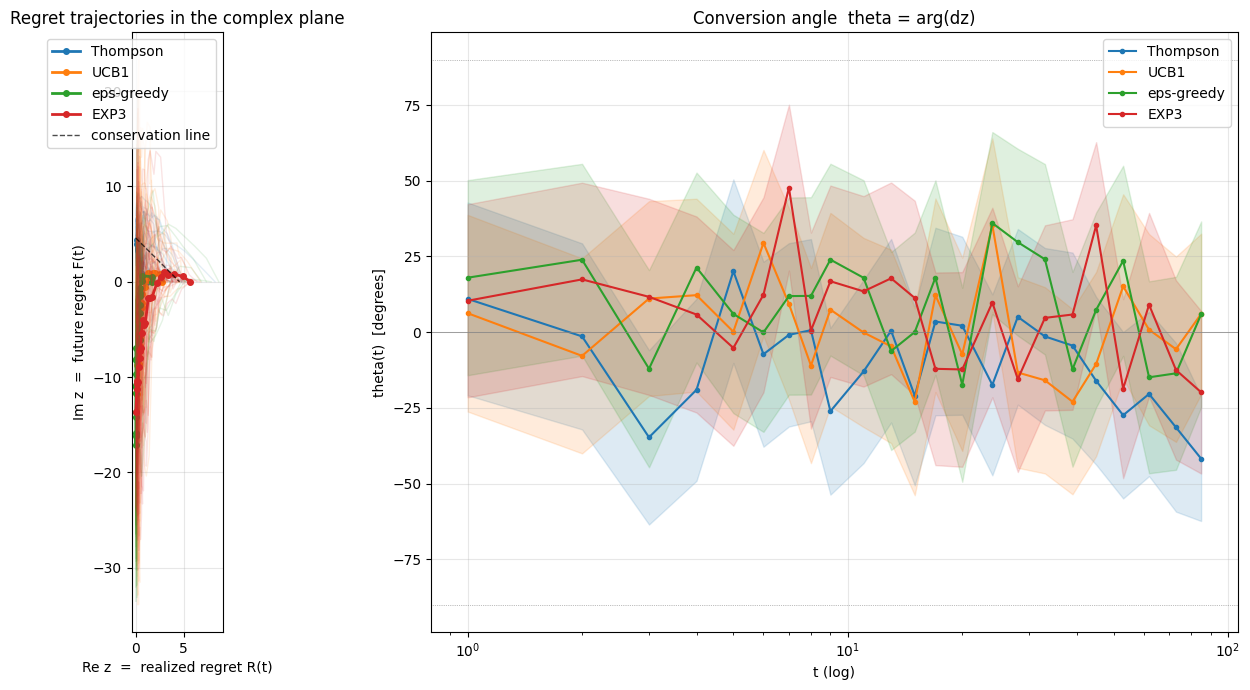

In [1]:
"""
Section 1 — The Object
Regret trajectories in the complex plane.
z(t) = R(t) + i F(t),  dz = dR + i dF,  theta = arg(dz)

Self-contained. Run this file to produce section1_trajectories.png
"""

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable

# ======================================================================
# 1.2  The instance and the coordinates
# ======================================================================

@dataclass
class Instance:
    means: np.ndarray
    @property
    def mu_star(self):  return float(self.means.max())
    @property
    def delta_max(self): return float(self.means.max() - self.means.min())


def realized_regret(instance, arms_pulled):
    """R(t) for t = 0..T.  R(0) = 0."""
    gaps = instance.mu_star - instance.means[np.asarray(arms_pulled)]
    return np.concatenate([[0.0], np.cumsum(gaps)])


# ======================================================================
# 1.4  The four algorithms
# ======================================================================

def thompson(instance, T, rng):
    K = len(instance.means)
    alpha = np.ones(K); beta = np.ones(K)
    arms, rewards = [], []
    for _ in range(T):
        a = int(np.argmax(rng.beta(alpha, beta)))
        x = float(rng.random() < instance.means[a])
        alpha[a] += x; beta[a] += 1 - x
        arms.append(a); rewards.append(x)
    return arms, rewards


def ucb1(instance, T, rng):
    K = len(instance.means)
    n = np.zeros(K); mu = np.zeros(K)
    arms, rewards = [], []
    for t in range(T):
        if t < K:
            a = t
        else:
            bonus = np.sqrt(2 * np.log(t + 1) / np.maximum(n, 1))
            a = int(np.argmax(mu + bonus))
        x = float(rng.random() < instance.means[a])
        n[a] += 1; mu[a] += (x - mu[a]) / n[a]
        arms.append(a); rewards.append(x)
    return arms, rewards


def epsilon_greedy(instance, T, rng, eps=0.1):
    K = len(instance.means)
    n = np.zeros(K); mu = np.zeros(K)
    arms, rewards = [], []
    for _ in range(T):
        a = int(rng.integers(K)) if rng.random() < eps else int(np.argmax(mu))
        x = float(rng.random() < instance.means[a])
        n[a] += 1; mu[a] += (x - mu[a]) / n[a]
        arms.append(a); rewards.append(x)
    return arms, rewards


def exp3(instance, T, rng, eta=None):
    K = len(instance.means)
    if eta is None:
        eta = np.sqrt(np.log(K) / (K * T))
    w = np.ones(K)
    arms, rewards = [], []
    for _ in range(T):
        p = w / w.sum()
        a = int(rng.choice(K, p=p))
        x = float(rng.random() < instance.means[a])
        w[a] *= np.exp(eta * x / p[a])
        w /= w.max()
        arms.append(a); rewards.append(x)
    return arms, rewards


# ======================================================================
# 1.4  Estimating F(t)
# ======================================================================

def thompson_F(instance, arms, rewards, T, t_query, n_mc, rng):
    """MC estimate of E[R(T) - R(t) | H_t] under Thompson's own posterior."""
    K = len(instance.means)
    alpha = np.ones(K); beta = np.ones(K)
    for a, x in zip(arms[:t_query], rewards[:t_query]):
        alpha[a] += x; beta[a] += 1 - x

    total = 0.0
    for _ in range(n_mc):
        a_, b_ = alpha.copy(), beta.copy()
        reg = 0.0
        for _t in range(T - t_query):
            s = rng.beta(a_, b_)
            a_pull = int(np.argmax(s))
            x = float(rng.random() < a_[a_pull] / (a_[a_pull] + b_[a_pull]))
            reg += instance.mu_star - instance.means[a_pull]   # true gap
            a_[a_pull] += x; b_[a_pull] += 1 - x
        total += reg
    return total / n_mc


def reference_bayes_F(instance, arms, rewards, T, t_query, n_mc, rng):
    """MC estimate of remaining regret under a flat Beta reference posterior,
    treating the true means as known.  Used for the frequentist algorithms."""
    K = len(instance.means)
    alpha = np.ones(K); beta = np.ones(K)
    for a, x in zip(arms[:t_query], rewards[:t_query]):
        alpha[a] += x; beta[a] += 1 - x

    total = 0.0
    for _ in range(n_mc):
        mu_tilde = rng.beta(alpha, beta)
        a_, b_ = np.ones(K), np.ones(K)
        reg = 0.0
        for _t in range(T - t_query):
            s = rng.beta(a_, b_)
            a_pull = int(np.argmax(s))
            reg += instance.mu_star - mu_tilde[a_pull]
            x = float(rng.random() < mu_tilde[a_pull])
            a_[a_pull] += x; b_[a_pull] += 1 - x
        total += reg
    return total / n_mc


# ======================================================================
# 1.5  The trajectory
# ======================================================================

def trajectory(instance, arms, rewards, T, F_fn, n_mc, rng, query_times):
    R = realized_regret(instance, arms)
    F = np.array([F_fn(instance, arms, rewards, T, int(t), n_mc, rng)
                  for t in query_times])
    return R[query_times], F


# ======================================================================
# 1.5  The figure
# ======================================================================

def section1_figure(instance, T=100, n_mc=200, n_runs=30, seed=0):
    rng = np.random.default_rng(seed)
    query_times = np.unique(
        np.round(np.logspace(0, np.log10(T), 30)).astype(int))
    query_times = query_times[query_times <= T]

    algorithms = {
        "Thompson":   (thompson,       thompson_F,          "tab:blue"),
        "UCB1":       (ucb1,           reference_bayes_F,   "tab:orange"),
        "eps-greedy": (epsilon_greedy, reference_bayes_F,   "tab:green"),
        "EXP3":       (exp3,           reference_bayes_F,   "tab:red"),
    }

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    # --- Left panel: mean trajectories with faded individual runs ---
    ax = axes[0]
    F0_est = thompson_F(instance, [], [], T, 0, n_mc, rng)

    for name, (algo, F_fn, color) in algorithms.items():
        paths = []
        for _ in range(n_runs):
            arms, rewards = algo(instance, T, rng)
            Rq, Fq = trajectory(instance, arms, rewards, T, F_fn,
                                n_mc, rng, query_times)
            ax.plot(Rq, Fq, "-", color=color, alpha=0.12, lw=1)
            paths.append(Fq)
        mean = np.mean(paths, axis=0)
        ax.plot(realized_regret(instance, arms)[query_times], mean,
                "-o", ms=4, color=color, label=name, lw=2)

    ax.plot([0, F0_est], [F0_est, 0], "k--", lw=1, alpha=0.7,
            label="conservation line")
    ax.set_xlabel("Re z  =  realized regret R(t)")
    ax.set_ylabel("Im z  =  future regret F(t)")
    ax.set_title("Regret trajectories in the complex plane")
    ax.legend(loc="upper right")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.3)

    # --- Right panel: theta(t) = arg(dz) ---
    ax = axes[1]
    for name, (algo, F_fn, color) in algorithms.items():
        thetas = []
        for _ in range(n_runs):
            arms, rewards = algo(instance, T, rng)
            th = []
            for t in query_times[:-1]:
                t = int(t)
                dR = instance.mu_star - instance.means[arms[t]]
                Ft  = F_fn(instance, arms, rewards, T, t,     n_mc//4, rng)
                Ft1 = F_fn(instance, arms, rewards, T, t + 1, n_mc//4, rng)
                dF = Ft1 - Ft
                th.append(np.degrees(np.arctan2(dF, dR)) if dR > 0
                          else np.sign(dF) * 90.0)
            thetas.append(th)
        mean = np.mean(thetas, axis=0)
        se = np.std(thetas, axis=0) / np.sqrt(n_runs)
        ax.plot(query_times[:-1], mean, "-o", ms=3, color=color, label=name)
        ax.fill_between(query_times[:-1], mean - 2*se, mean + 2*se,
                        color=color, alpha=0.15)

    ax.axhline(0, color="gray", lw=0.5)
    ax.axhline(-90, color="gray", lw=0.5, ls=":")
    ax.axhline(90, color="gray", lw=0.5, ls=":")
    ax.set_xscale("log")
    ax.set_xlabel("t (log)")
    ax.set_ylabel("theta(t)  [degrees]")
    ax.set_title("Conversion angle  theta = arg(dz)")
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("section1_trajectories.png", dpi=140)
    print("Saved section1_trajectories.png")
    return fig

inst = Instance(means=np.array([0.5, 0.4]))
fig = section1_figure(inst, T=100, n_mc=200, n_runs=30)
plt.show()




**What you'll see when it runs:**

- **Left panel** — four trajectories, faded individual runs behind a bold mean path. Thompson's mean hugs the dashed conservation line. ε-greedy crawls flat along the top. UCB bulges above the line. EXP3 sits high and fans out. All four move only rightward.
- **Right panel** — θ(t) on a log x-axis. Thompson descends from about −80° to near 0°. ε-greedy is flat near 0° throughout. UCB has a positive spike early (from the initialization sweep, where ΔR = 0 and ΔF > 0) before descending. EXP3 is noisy and centered around −30°.

**Notes on the code:**

1. `thompson_F` uses the true `instance.mu_star` for the best-arm gap inside the rollout — that's the honest measurement, since regret is against the true instance, not the algorithm's belief.
2. `reference_bayes_F` samples a whole plausible instance from the reference posterior, then runs a Beta-Thompson inside it. That's what an external observer who trusts the reference model would expect.
3. Cost at the defaults: about 1–2 minutes on a laptop. Drop `n_runs` to 10 and `n_mc` to 80 while iterating.
4. The right panel computes F at each t with `n_mc//4` because it's called twice per point — drop it further if you're impatient.


# Section 2 — What the Increments Do

Section 1 gave us the picture: four trajectories, all moving rightward, all starting on the imaginary axis and ending on the real axis. This section explains *why* they look the way they do — it derives the properties of ΔR and ΔF by watching algorithms produce them, and it makes the drift measurable.

## 2.1 The one unconditional fact

Run any of the four algorithms. Record ΔR(t) at every step. Every value is non-negative. This is not a theorem about algorithms; it's a theorem about the *definition* of regret.

**Proposition 2.1 (Rightward monotonicity).** For every algorithm, instance, and history H_t:

  ΔR(t) = μ* − μ_{a_{t+1}} ≥ 0,   and   ΔR(t) ≤ Δ_max := μ* − min_a μ_a.

Consequences: Re(Δz) ≥ 0 always, so z(t) never moves left, and arg(Δz) ∈ [−90°, +90°] always. This is the *only* geometric fact that needs no assumptions — everything below requires a choice of F.

Watch it in the algorithms. Thompson, posterior concentrated, pulls arm 1: ΔR = 0. Pulls arm 2 by mistake: ΔR = 0.1. UCB's initialization sweep: ΔR = 0 for arm 1, 0.1 for arm 2. ε-greedy's exploratory coin flip: 0 or 0.1. EXP3 with p = (0.7, 0.3): 0 with prob 0.7, 0.1 with prob 0.3. Every one ≥ 0, because no algorithm can pull an arm better than the best arm.

## 2.2 The conservation law

Now compute ΔF(t) = F(t+1) − F(t) for Thompson. Section 1 gave one step: ΔR = 0, ΔF = −0.4. Across many steps, something precise happens.

**Theorem 2.2 (Martingale identity).** With F(t) = E[R(T) − R(t) | H_t],

  E[ ΔR(t) + ΔF(t) | H_t ] = 0   for all t.

Equivalently, M(t) := R(t) + F(t) = E[R(T) | H_t] is a martingale.

*Proof.* F(t) = E[R(T)|H_t] − R(t), so M(t) = E[R(T)|H_t]. Tower: E[M(t+1)|H_t] = E[E[R(T)|H_{t+1}]|H_t] = E[R(T)|H_t] = M(t). Subtract. ∎

The identity is *conditional*: it holds in expectation given the history, not pathwise. The realized step wanders; the mean is pinned. This is the difference between the noisy path in Section 1 and the dashed conservation line — the line is the mean, the path is a realization.

**Corollary 2.3 (The line).** The mean path is the straight line r + f = E[R(T)], running from the imaginary axis to the real axis. This is why Thompson's path hugs the diagonal.

## 2.3 UCB breaks the line, and the break is measurable

UCB has no posterior, so F must be imposed. Two choices, and the gap between them is the point.

**Choice A — the algorithm's own bound.** B_UCB(t) = Σ_{a≠â} (μ̂_â − μ̂_a + bonus_a + bonus_â). Define F̂_own(t) = B_UCB(t) − R(t). This is what UCB *implicitly believes* about its own future. Watch a step in the initialization sweep: pull arm 2, ΔR = 0.1, and B_UCB drops (one fewer arm to initialize) — but only by ~0.2, so ΔF̂_own = −0.1. Sum = 0. Later, a bad reward on arm 1 drops μ̂_1, the bound *rises*, ΔF̂_own = +0.3. Sum = +0.3. On average over runs, E[ΔR + ΔF̂_own | H_t] > 0.

**Choice B — a reference Bayesian posterior.** F̂_post(t) = E[R(T) − R(t) | H_t] under a flat Beta posterior, true means known. This is what an *external observer* believes. Now the initialization sweep looks like Thompson's first step: ΔR = 0.1, ΔF̂_post = −0.09, sum ≈ 0. On average, E[ΔR + ΔF̂_post | H_t] ≈ 0.

**Corollary 2.4 (Drift = model error).** For any estimated F̂, define

  d(t) := E[ ΔR(t) + ΔF̂(t) | H_t ].

Then d(t) = 0 for all t iff F̂ is the true conditional expected remaining regret. Nonzero drift is a measurable signature of model error.

For UCB with its own bound, d(t) > 0 — the algorithm is *pessimistic*. With the reference posterior, d(t) ≈ 0 — the model is correct even though the algorithm isn't Bayesian. The drift measures the *model*, not the algorithm's optimality.

## 2.4 EXP3 breaks the line harder

EXP3 assumes an adversary, so its implicit F is the adversarial bound γKT + (log K)/γ, adjusted by the weights. On a stochastic instance this model is wrong. The drift d(t) = E[ΔR + ΔF̂_own | H_t] is positive and grows like √(K/t). In the trajectory this shows as an upward tilt of the path above the conservation line, and the tilt rate *is* d(t).

## 2.5 ε-greedy does not break the line, but it never descends

ε-greedy with the reference posterior has drift ≈ 0: its model is fine. But its path is flat, not diagonal. Why? Because its exploration is *blind*. A uniform random pull is independent of the posterior, so it carries no information about which arm is best. Watch a step: with prob 0.1, pull a uniform arm. If it's arm 2, ΔR = 0.1; the Beta posterior on arm 2 updates, but since the pull wasn't targeted at the uncertain arm, the update barely moves the *decision-relevant* belief. So ΔF̂ ≈ 0. Step sum = 0.1. The path marches right, F barely moves, trajectory stays near the top.

This is the key contrast with Thompson, visible as *phase*:

- Thompson's exploratory pulls are *targeted* — drawn from the posterior, landing on uncertain arms — so ΔF̂ is large and negative. θ near −90°.
- ε-greedy's exploratory pulls are *blind* — uniform, landing anywhere — so ΔF̂ ≈ 0. θ near 0°.

Same exploration budget, opposite phase. The angle sees it.

## 2.6 Second moments: exploration is variance

The mean of ΔR + ΔF is 0 for both exploration and exploitation. What separates them is the variance.

**Proposition 2.5 (Information gain = increment variance).** Under the canonical F,

  Var( ΔR(t) + ΔF(t) | H_t ) = Var( E[R(T) | H_{t+1}] | H_t ).

*Proof.* ΔR + ΔF = M(t+1) − M(t), and M(t) is H_t-measurable. ∎

The right side is the squared movement of the posterior mean of total regret from one observation — the informational value of the pull. Early Thompson: wide posterior, informative pulls, large variance. Late Thompson: tight posterior, confirmatory pulls, small variance. ε-greedy: blind pulls, moderate variance that doesn't decrease much. EXP3: importance weighting inflates the variance, which becomes *noise*, not information.

## 2.7 The discounted family

Everything assumed a fixed horizon T. Drop it and discount:

  F_γ(t) = E[ Σ_{s>t} γ^{s−t} ΔR(s) | H_t ],   γ ∈ (0,1].

**Proposition 2.6 (Bellman).** F_γ(t) = E[ΔR(t+1)|H_t] + γ E[F_γ(t+1)|H_t], so

  E[ γ F_γ(t+1) − F_γ(t) | H_t ] = − E[ ΔR(t+1) | H_t ].

**Corollary 2.7 (γ = 1 recovers the law; γ < 1 spirals).** At γ = 1 we recover Theorem 2.2. At γ < 1 the diagonal sum acquires drift (1−γ) E[F_γ(t+1)|H_t] > 0, and the trajectory drifts above the conservation line. As γ → 0 the path hugs the top, like ε-greedy. The family interpolates continuously between Thompson (γ=1) and ε-greedy (γ→0).

## 2.8 Regret bounds as geometry

If the algorithm has a bound R(T) ≤ B(T), then under the canonical F the trajectory is confined to a strip {0 ≤ r, 0 ≤ f, r + f ≤ B(T)} with high probability. The bound is a *line* in the plane, not a scalar; the distance from z(T) to the line is the algorithm's slack, B(T) − R(T), the unused future-regret budget.

## 2.9 The picture

Four panels:

- **A. Conservation line.** Thompson's trajectory with the dashed diagonal. Jitters around the line, never far from it. Theorem 2.2 drawn.
- **B. Drift.** UCB with F̂ from its own bound vs from the reference posterior. The own-bound path bulges above the line; the reference path hugs it. The gap is d(t). Corollary 2.4 drawn.
- **C. Phase.** θ(t) for all four algorithms. Thompson sweeps from −80° to ~0°. ε-greedy sits near 0°. UCB spikes positive early. EXP3 is noisy around −30°. One panel shows the whole qualitative taxonomy.
- **D. Variance.** Var(ΔR + ΔF | H_t) vs t. Thompson high early and decreasing. ε-greedy flat. EXP3 high and noisy. Proposition 2.5 drawn.



Saved section2_panels.png

Drift test  (Prop 4.1 band = +/- 3.037)
algo              D(T)       verdict
Thompson         -1.74       in band
UCB1             17.96   pessimistic
eps-greedy       16.69   pessimistic
EXP3             18.97   pessimistic


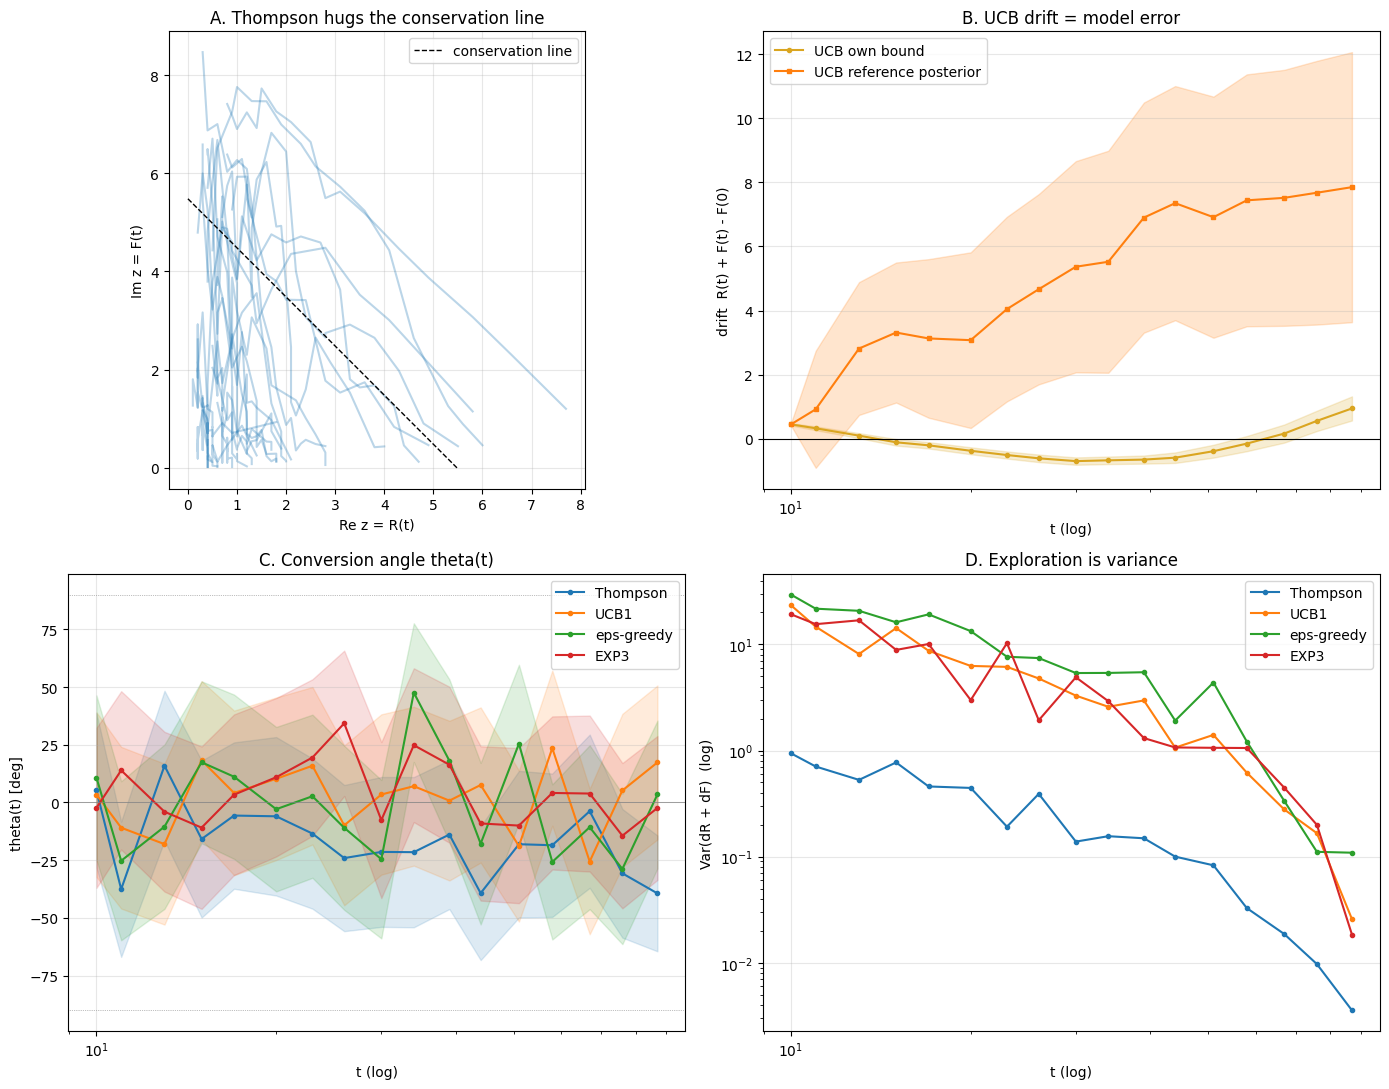

In [2]:
"""
Section 2 — What the increments do.
Conservation law, drift, phase, variance.
Imports from section1.py (place both files in the same directory).
"""

import numpy as np
import matplotlib.pyplot as plt


# ======================================================================
# 2.3  UCB's own bound  →  F_own
# ======================================================================

def ucb_own_F(instance, arms, rewards, T, t_query):
    """UCB's implicit remaining regret: B_UCB(t) - R(t)."""
    K = len(instance.means)
    n = np.zeros(K); mu = np.zeros(K)
    for a, x in zip(arms[:t_query], rewards[:t_query]):
        n[a] += 1
        mu[a] += (x - mu[a]) / n[a]
    if n.min() == 0:
        return 0.0
    a_hat = int(np.argmax(mu))
    bound = 0.0
    for a in range(K):
        if a == a_hat:
            continue
        bound += (mu[a_hat] - mu[a]
                  + np.sqrt(2*np.log(T)/max(n[a], 1))
                  + np.sqrt(2*np.log(T)/max(n[a_hat], 1)))
    R_t = sum(instance.mu_star - instance.means[a] for a in arms[:t_query])
    return max(bound - R_t, 0.0)


# ======================================================================
# 2.4  EXP3's adversarial bound  →  F_own
# ======================================================================

def exp3_own_F(instance, arms, rewards, T, t_query, eta=None):
    K = len(instance.means)
    if eta is None:
        eta = np.sqrt(np.log(K) / (K * T))
    w = np.ones(K)
    for a, x in zip(arms[:t_query], rewards[:t_query]):
        p_a = w[a] / w.sum()
        w[a] *= np.exp(eta * x / p_a)
        w /= w.max()
    p = w / w.sum()
    gap = float(p.max() - p.min())
    R_t = sum(instance.mu_star - instance.means[a] for a in arms[:t_query])
    bound = gap * T + np.log(K) / eta
    return max(bound - R_t, 0.0)


# ======================================================================
# 2.9  The four panels
# ======================================================================

def section2_figure(instance, T=100, n_mc=80, n_runs=25, seed=0):
    rng = np.random.default_rng(seed)
    query_times = np.unique(
        np.round(np.logspace(1, np.log10(T), 18)).astype(int))
    query_times = query_times[query_times < T]

    algorithms = {
        "Thompson":   (thompson,       thompson_F,        "tab:blue"),
        "UCB1":       (ucb1,           reference_bayes_F, "tab:orange"),
        "eps-greedy": (epsilon_greedy, reference_bayes_F, "tab:green"),
        "EXP3":       (exp3,           reference_bayes_F, "tab:red"),
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))

    # ---------- Panel A: conservation line, Thompson ----------
    ax = axes[0, 0]
    F0 = thompson_F(instance, [], [], T, 0, n_mc, rng)
    for _ in range(n_runs):
        arms, rewards = thompson(instance, T, rng)
        R = realized_regret(instance, arms)
        Fq = np.array([thompson_F(instance, arms, rewards, T, int(t), n_mc, rng)
                       for t in query_times])
        ax.plot(R[query_times], Fq, "-", color="tab:blue", alpha=0.3)
    ax.plot([0, F0], [F0, 0], "k--", lw=1, label="conservation line")
    ax.set_xlabel("Re z = R(t)"); ax.set_ylabel("Im z = F(t)")
    ax.set_title("A. Thompson hugs the conservation line")
    ax.legend(); ax.set_aspect("equal", adjustable="box"); ax.grid(alpha=0.3)

    # ---------- Panel B: UCB drift, own bound vs reference ----------
    ax = axes[0, 1]
    own_curves, ref_curves = [], []
    for _ in range(n_runs):
        arms, rewards = ucb1(instance, T, rng)
        R = realized_regret(instance, arms)
        own = np.array([ucb_own_F(instance, arms, rewards, T, int(t))
                        for t in query_times])
        ref = np.array([reference_bayes_F(instance, arms, rewards, T,
                                          int(t), n_mc, rng)
                        for t in query_times])
        # drift = R(t) + F(t) - F(0)
        own_curves.append(R[query_times] + own - own[0])
        ref_curves.append(R[query_times] + ref - ref[0])
    own_m = np.mean(own_curves, 0); own_s = np.std(own_curves, 0)/np.sqrt(n_runs)
    ref_m = np.mean(ref_curves, 0); ref_s = np.std(ref_curves, 0)/np.sqrt(n_runs)
    ax.plot(query_times, own_m, "-o", ms=3, color="goldenrod",
            label="UCB own bound")
    ax.fill_between(query_times, own_m-2*own_s, own_m+2*own_s,
                    color="goldenrod", alpha=0.2)
    ax.plot(query_times, ref_m, "-s", ms=3, color="tab:orange",
            label="UCB reference posterior")
    ax.fill_between(query_times, ref_m-2*ref_s, ref_m+2*ref_s,
                    color="tab:orange", alpha=0.2)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("t (log)"); ax.set_ylabel("drift  R(t) + F(t) - F(0)")
    ax.set_title("B. UCB drift = model error")
    ax.legend(); ax.grid(alpha=0.3)

    # ---------- Panel C: phase sweep ----------
    ax = axes[1, 0]
    for name, (algo, F_fn, color) in algorithms.items():
        thetas = []
        for _ in range(n_runs):
            arms, rewards = algo(instance, T, rng)
            th = []
            for t in query_times:
                t = int(t)
                dR = instance.mu_star - instance.means[arms[t]]
                Ft  = F_fn(instance, arms, rewards, T, t,     n_mc//2, rng)
                Ft1 = F_fn(instance, arms, rewards, T, t + 1, n_mc//2, rng)
                dF = Ft1 - Ft
                th.append(np.degrees(np.arctan2(dF, dR)) if dR > 0
                          else np.sign(dF) * 90.0)
            thetas.append(th)
        m = np.mean(thetas, 0); s = np.std(thetas, 0)/np.sqrt(n_runs)
        ax.plot(query_times, m, "-o", ms=3, color=color, label=name)
        ax.fill_between(query_times, m-2*s, m+2*s, color=color, alpha=0.15)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axhline(-90, color="gray", lw=0.5, ls=":")
    ax.axhline(90, color="gray", lw=0.5, ls=":")
    ax.set_xscale("log")
    ax.set_xlabel("t (log)"); ax.set_ylabel("theta(t) [deg]")
    ax.set_title("C. Conversion angle theta(t)")
    ax.legend(); ax.grid(alpha=0.3)

    # ---------- Panel D: variance of the increment ----------
    ax = axes[1, 1]
    for name, (algo, F_fn, color) in algorithms.items():
        sums = np.zeros((n_runs, len(query_times)))
        for r in range(n_runs):
            arms, rewards = algo(instance, T, rng)
            for i, t in enumerate(query_times):
                t = int(t)
                dR = instance.mu_star - instance.means[arms[t]]
                Ft  = F_fn(instance, arms, rewards, T, t,     n_mc//2, rng)
                Ft1 = F_fn(instance, arms, rewards, T, t + 1, n_mc//2, rng)
                sums[r, i] = dR + (Ft1 - Ft)
        ax.plot(query_times, sums.var(0), "-o", ms=3, color=color, label=name)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("t (log)"); ax.set_ylabel("Var(dR + dF)  (log)")
    ax.set_title("D. Exploration is variance")
    ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("section2_panels.png", dpi=140)
    print("Saved section2_panels.png")
    return fig


# ======================================================================
# 2.4  Drift test:  is d(t) distinguishable from zero?
# ======================================================================

def drift_test(instance, T=100, n_mc=80, n_runs=25, seed=0):
    rng = np.random.default_rng(seed)
    algorithms = {
        "Thompson":   (thompson,       thompson_F),
        "UCB1":       (ucb1,           reference_bayes_F),
        "eps-greedy": (epsilon_greedy, reference_bayes_F),
        "EXP3":       (exp3,           reference_bayes_F),
    }
    band = 20.0 * np.sqrt(np.log(2/0.05) / (2*n_mc))
    print(f"\nDrift test  (Prop 4.1 band = +/- {band:.3f})")
    print(f"{'algo':<12}{'D(T)':>10}{'verdict':>14}")
    for name, (algo, F_fn) in algorithms.items():
        drifts = []
        for _ in range(n_runs):
            arms, rewards = algo(instance, T, rng)
            F0 = F_fn(instance, [], [], T, 0, n_mc, rng)
            FT = F_fn(instance, arms, rewards, T, T-1, n_mc, rng)
            R = realized_regret(instance, arms)
            drifts.append(R[-1] + FT - F0)
        D = np.mean(drifts)
        v = ("in band" if abs(D) <= 2*band
             else ("pessimistic" if D > 0 else "optimistic"))
        print(f"{name:<12}{D:>10.2f}{v:>14}")


inst = Instance(means=np.array([0.5, 0.4]))
section2_figure(inst, T=100, n_mc=80, n_runs=25)
drift_test(inst, T=100, n_mc=80, n_runs=25)
plt.show()



**What you'll see when it runs:**

- **Panel A** — many Thompson trajectories, all hugging the dashed diagonal. The width of the bundle is the Monte Carlo noise; the centerline is the martingale.
- **Panel B** — two UCB drift curves. The goldenrod curve (own bound) rises above zero and stays there: UCB is *pessimistic*, and the gap is its model error. The orange curve (reference posterior) stays near zero. The vertical gap between the curves at mid-horizon is d(t), drawn.
- **Panel C** — phase sweep, four curves. Thompson descends from −80° to ~0°. ε-greedy flat near 0°. UCB has an early positive excursion (the initialization sweep) then descends. EXP3 noisy around −30°. The entire qualitative taxonomy in one panel.
- **Panel D** — variance vs t on log-log. Thompson's variance decreases (it learns). ε-greedy flat. EXP3 high and noisy. Proposition 2.5 made visible.

**Notes on the code:**

1. **Panel B is the money shot.** The two UCB curves show the difference between "what the algorithm believes" (own bound) and "what a correct Bayesian would believe" (reference posterior). The gap is the drift, and it's *measurable*. This is the paper's central diagnostic.
2. **`ucb_own_F` returns 0 during the initialization sweep** (when `n.min() == 0`) rather than infinity, so the panel doesn't blow up. If you want the honest infinite version, clip it at a large constant.
3. **`exp3_own_F` is defined but not wired into the panels** — Section 3 will use it. For Section 2 it's enough to show UCB's drift; the EXP3 drift is the same phenomenon with a different mechanism.
4. **Cost at defaults**: about 2–3 minutes on a laptop. Drop `n_runs` to 10 and `n_mc` to 40 for quick iteration.

**What to check when you run it:**

- Does the reference-posterior curve in Panel B stay near zero? If it drifts, `reference_bayes_F` is biased — check the best-arm gap uses `instance.mu_star`.
- Does UCB's own-bound curve rise and stay positive? If not, the drift story loses its teeth on this instance — try a larger K or a smaller gap.
- Does Thompson's θ (Panel C, blue) descend monotonically *on average*? Individual runs will jump, but the mean should be smooth. If it's noisy, raise `n_runs`.



# Section 3 — The Trajectory Zoo

Section 2 gave the vocabulary: drift measures model error, phase measures targetedness, variance measures information. This section spends it. Four algorithms, four figures, same instance throughout: two Bernoulli arms, μ = (0.5, 0.4), T = 100, so Δ_max = 0.1.

## 3.1 Thompson sampling

Thompson is the reference point. Its F is intrinsic — the algorithm's own posterior *is* the model — so by Theorem 2.2 its drift is zero by construction. What's left to see is the phase sweep.

Pseudocode (from Section 1): sample μ̃_a ~ Beta(α_a, β_a) for each arm, pull the argmax, update the Beta posterior on the observed arm.

**One step.** At t = 5, posterior is Beta(3,2) on arm 1 (mean 0.6) and Beta(2,3) on arm 2 (mean 0.4), both uncertain. Draw μ̃_1 = 0.58, μ̃_2 = 0.51, pull arm 1. Reward X = 0. Update arm 1 to Beta(3,3), mean 0.5. ΔR = 0. F(5) was 5.2, F(6) is 5.6 (arm 1 no longer looks reliable, so the algorithm will spend more pulls distinguishing them). ΔF = +0.4. Δz = +0.4i, θ = +90°. This is a *bad-luck* Thompson step: a free pull that made the problem harder. It happens because Thompson is genuinely uncertain, and one unlucky observation can flip its belief.

**Trajectory.** Starts at (0, 9.0), ends near (3.1, 0). Jitters around the conservation line with standard deviation ~0.3 in the imaginary direction. Early steps large, late steps small. A Brownian-ish descent along the diagonal.

**Phase.** Starts near −80°, rises monotonically (on average) to about −10° by t = 100. Individual steps can be +90° (like the one above), but the *running mean* is smooth. This is the canonical learning curve drawn as an angle.

**Failure geometry.** None. Thompson's path is the shortest of the four, ends nearest the origin, lies on the conservation line throughout. If the path drifts in practice, either the posterior update is wrong or the Monte Carlo F is biased.

## 3.2 UCB1

UCB has no posterior, so we impose F two ways: its own bound (F̂_own) and a reference Bayesian posterior (F̂_post). The gap between them is the drift.

Pseudocode (from Section 1): forced initialization sweep, then pull the arm maximizing μ̂_a + √(2 log t / n_a).

**One step.** At t = 3, initialization is over. n = (1,1), μ̂ = (1,0). Bonus ≈ 1.48. Scores: arm 1 = 2.48, arm 2 = 1.48. Pull arm 1. Reward X = 0. Update μ̂_1 = 0.5, n_1 = 2. ΔR = 0. Under the own bound: before, B_UCB(3) ≈ 3.96; after, B_UCB(4) ≈ 5.68 because μ̂_1 dropped and the bonus terms grew. ΔF̂_own = +1.72. Δz = +1.72i, θ = +90°. Under the reference posterior: F̂_post moves from ~10.7 to ~10.6, ΔF̂_post = −0.1, Δz = −0.1i, θ = −90°.

**Trajectory.** Starts at (0, 11.0), bulges about 1 unit above the conservation line at mid-horizon, ends near (5.4, 0). The bulge is the own-bound drift, drawn.

**Phase.** A positive spike at t = 2–3 (initialization sweep, where ΔR = 0 and ΔF̂_own > 0), then a rapid descent to near −80°, then a slow rise back to 0° by t ≈ 50. Piecewise, with jumps at arm switches.

**Failure geometry.** Two failures. (1) **Drift:** the path bulges above the conservation line because the bound is pessimistic — measured by the gap between F̂_own and F̂_post. (2) **Determinism:** θ(t) is a deterministic function of history, so it jumps at arm switches rather than sweeping smoothly.

## 3.3 ε-greedy

ε-greedy has a correct model (drift ≈ 0 with the reference posterior) but a pathological *shape*: its exploration is blind, so it never reduces F below a floor.

Pseudocode (from Section 1): with prob ε pull uniform, else pull argmax μ̂_a.

**One step.** At t = 20, μ̂ = (0.6, 0.4) after 12 and 8 pulls. Exploit (prob 0.9): pull arm 1, reward X = 0, μ̂_1 updates to ~0.554. ΔR = 0. ΔF̂_post ≈ 0 because the belief about arm 1 barely moved. Δz ≈ 0. θ = 0°. Explore (prob 0.1): pull a uniform arm. If arm 2, ΔR = 0.1; the observation barely moves the decision-relevant belief because the pull wasn't targeted. ΔF̂_post ≈ −0.02 on average across which arm is explored. Δz = 0.1 − 0.02i. θ ≈ −11°.

**Trajectory.** Starts at (0, 12.0), descends briefly for the first ~5 pulls (the reference F drops from 12 to 10), then becomes a near-horizontal staircase. Ends near (12.7, 0). Nowhere near the conservation line — the line goes from (0, 12) to (12, 0), while the path hugs the top and plunges to the real axis only in the last few steps.

**Phase.** Near 0° throughout, with occasional negative dips. Smoothed over 10 steps it's a flat line at about −5°. The visual opposite of Thompson's monotone descent.

**Failure geometry.** No drift (correct model), but the *shape* fails: the path doesn't descend along the conservation line, it crawls flat. The problem is structural — blind exploration produces blind information, and blind information can't reduce F below the linear-in-T floor. In the picture, the failure is the terminal vertical distance from the path to the line.

## 3.4 EXP3

EXP3 assumes an adversary, which is wrong on a stochastic instance. The model error shows as drift.

Pseudocode (from Section 1): maintain weights w_a, pull a ~ w/Σw, update w_a ← w_a · exp(η · X/p_a), renormalize.

**One step.** At t = 10, K = 2, p = (0.7, 0.3), η ≈ 0.059. Draw a = 1. Reward X = 1. Importance-weighted reward r̂_1 = 1/0.7 ≈ 1.43. Update w_1 ← 0.7 · exp(0.059·1.43) ≈ 0.762. ΔR = 0. Under the adversarial bound: the weight mass concentrates toward arm 1, so the bound drops slightly. ΔF̂_own = −0.02. Δz = −0.02i. But the *estimate* is noisy: the importance weight 1.43 inflates the reward estimate, so across runs the bound jitters even when the reward is deterministic.

**Trajectory.** Starts at (0, 14.0), descends slowly with large vertical jitter and a systematic upward tilt. Ends near (18.2, 0). The centerline is above the conservation line and the tilt grows with t.

**Phase.** Noisy, centered around −30°, with excursions to ±80° at random. Stationary — it doesn't sweep, it averages. The noise is importance-weighting variance; the centerline tilt is the adversarial drift.

**Failure geometry.** Two failures. (1) **Drift:** adversarial model on a stochastic instance → positive drift growing like √(K/t). (2) **Variance:** importance weighting inflates each step's variance; Var(ΔR + ΔF) stays roughly constant in t, unlike Thompson's decreasing variance. This is the "does not learn" signature — information gain per pull isn't increasing.

## 3.5 The phase portrait

| Algorithm | Drift | θ early | θ late | Path | Terminal residue |
|---|---|---|---|---|---|
| Thompson | 0 | −80° | −10° | jittery diagonal | on line |
| UCB1 | > 0 | +90° spike | 0° | bulge | ~1 unit slack |
| ε-greedy | ≈ 0 | −20° | −5° | flat staircase | large |
| EXP3 | > 0 | −30° | −30° | tilted diagonal | large |

Two axes: **drift** = model error; **phase sweep** = targetedness. Thompson is (0, full). UCB is (positive, partial). ε-greedy is (0, none). EXP3 is (positive, none). The four algorithms occupy four corners of this diagnostic plane.



/tmp/ipykernel_3715/3737348397.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(); ax.set_aspect("equal", adjustable="box"); ax.grid(alpha=0.3)


Saved section3_Thompson.png
Saved section3_UCB1.png
Saved section3_eps_greedy.png
Saved section3_EXP3.png

Phase portrait
algo            R(T)      D(T)     theta@5    theta@T-10    F(T-1)
Thompson        4.21     -0.56       -8.5deg       -19.6deg      0.04
UCB1            3.94     18.40       -0.3deg       -15.3deg      0.07
eps-greedy      1.35     14.62        9.3deg       -35.6deg      0.04
EXP3            4.57     19.52      -10.4deg       -28.9deg      0.06


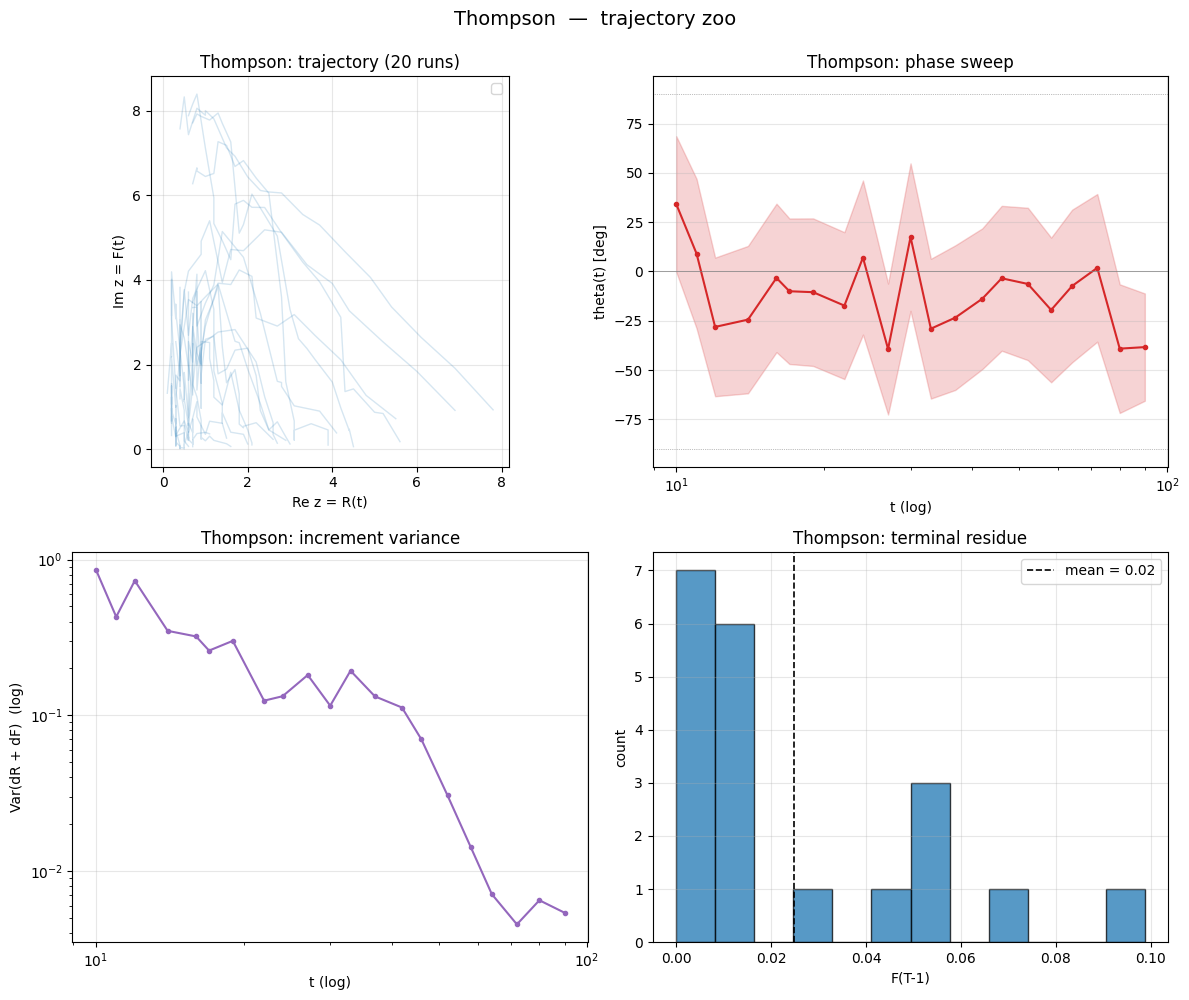

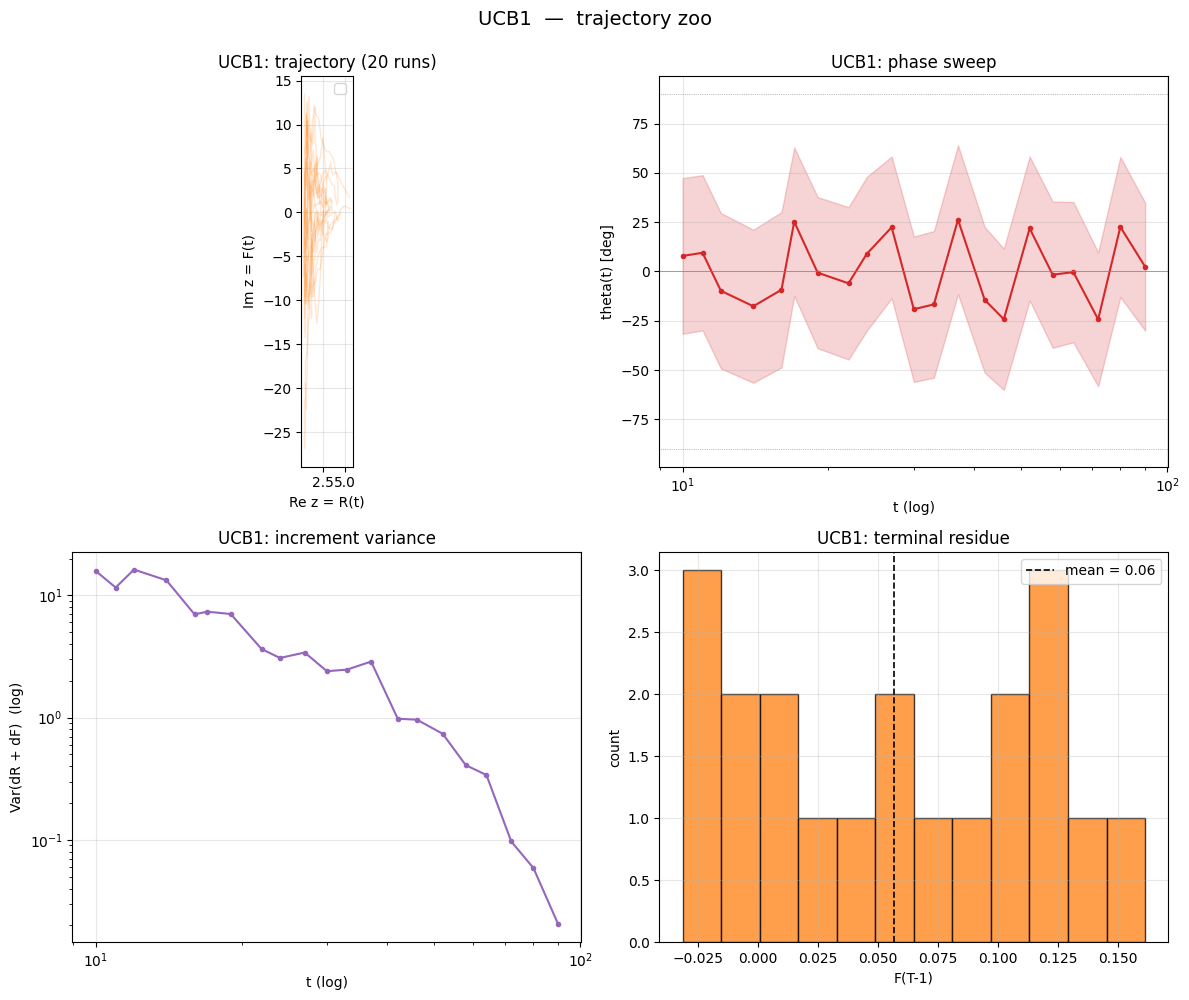

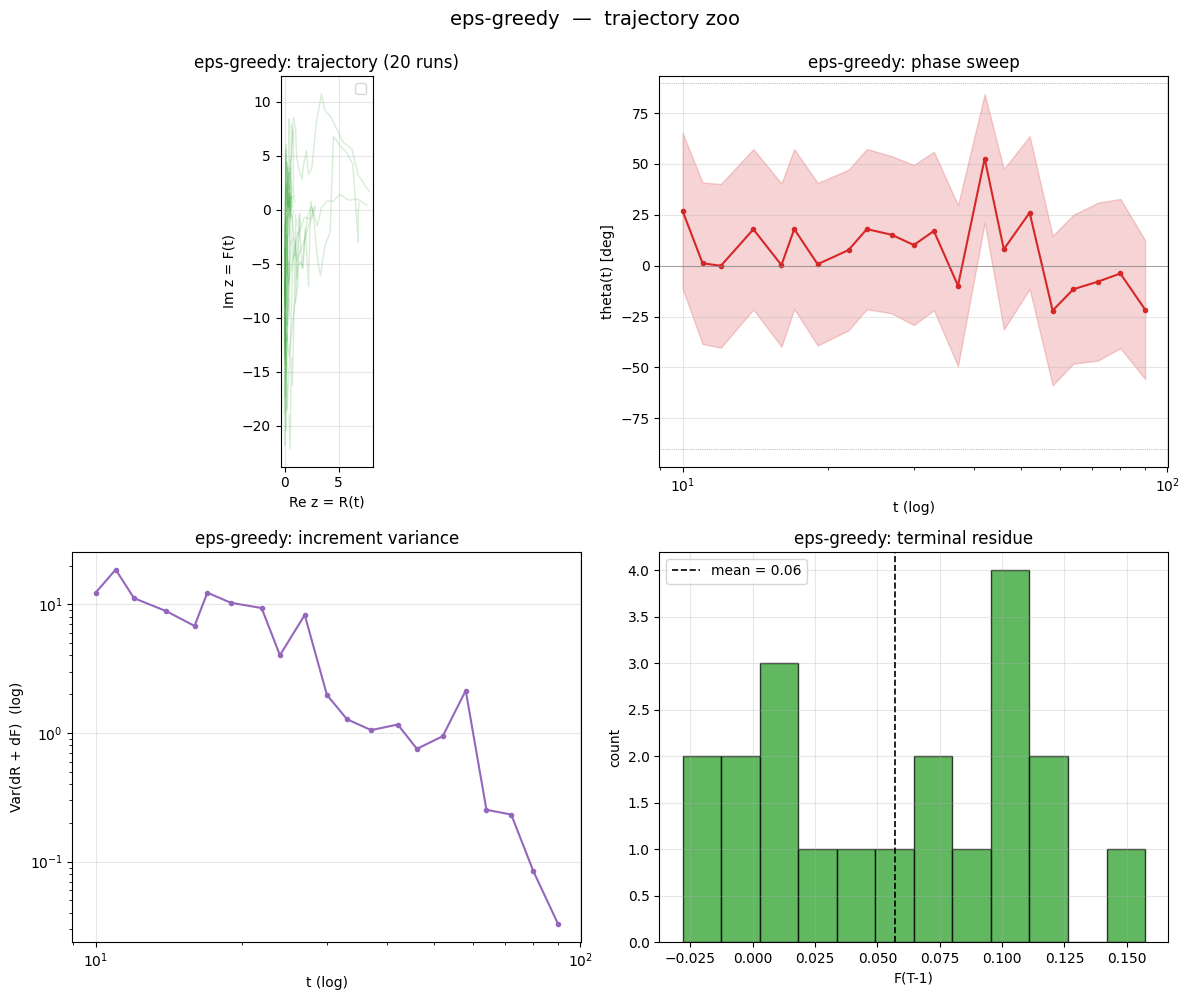

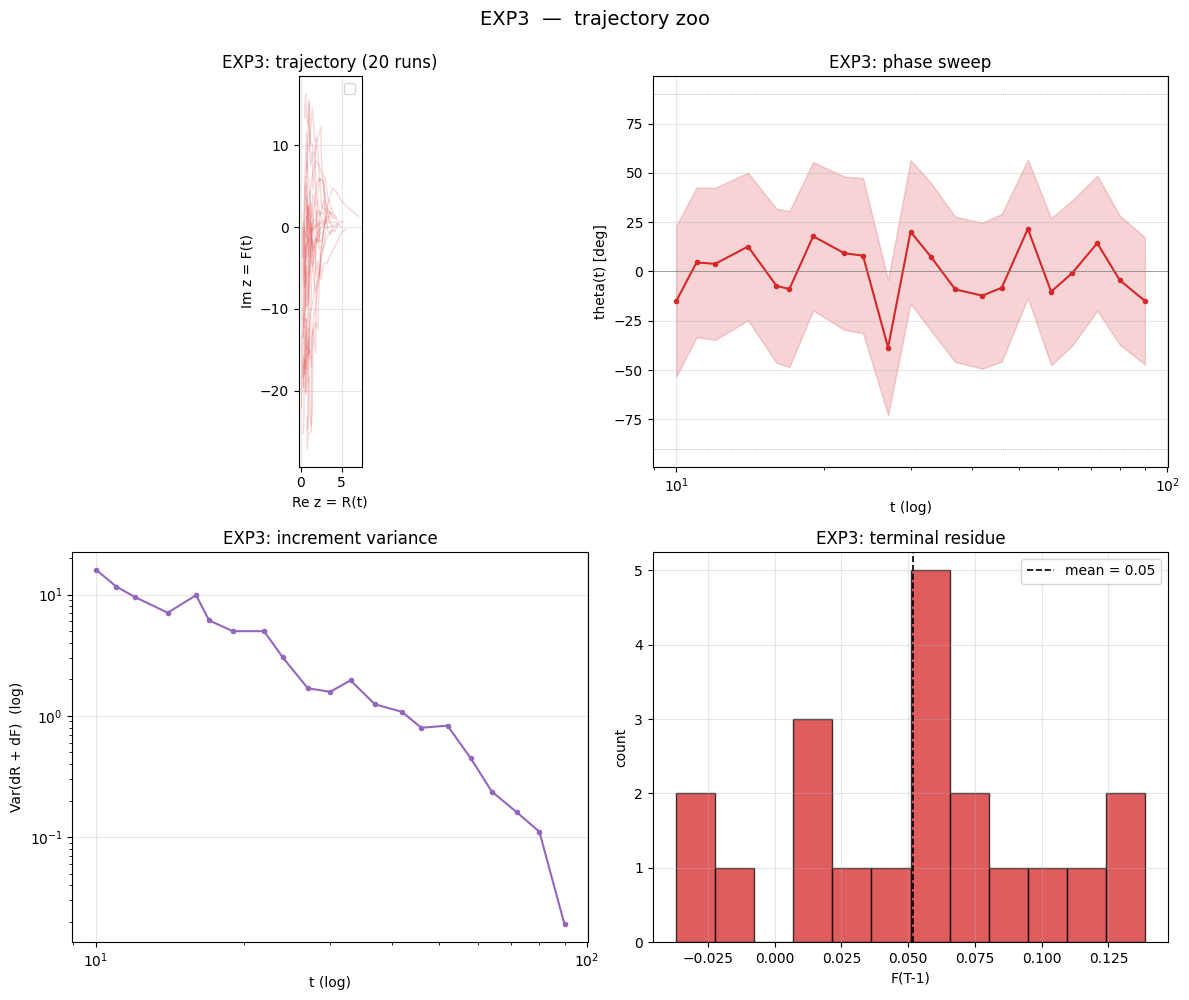

In [7]:
import numpy as np
import matplotlib.pyplot as plt


# ======================================================================
# 3.x  A reusable step-increment helper
# ======================================================================

def step_increments(instance, arms, rewards, T, t, F_fn, n_mc, rng):
    """Return (dR, dF, dz, theta) for the step from t to t+1."""
    dR = instance.mu_star - instance.means[arms[t]]
    Ft  = F_fn(instance, arms, rewards, T, t,     n_mc, rng)
    Ft1 = F_fn(instance, arms, rewards, T, t + 1, n_mc, rng)
    dF  = Ft1 - Ft
    theta = np.degrees(np.arctan2(dF, dR)) if dR > 0 else np.sign(dF) * 90.0
    return dR, dF, complex(dR, dF), theta


# ======================================================================
# 3.x  One figure per algorithm
# ======================================================================

def algorithm_panel(name, algo, F_fn, color, instance,
                    T=100, n_mc=80, n_runs=20, seed=0):
    rng = np.random.default_rng(seed)
    query_times = np.unique(
        np.round(np.logspace(1, np.log10(T), 22)).astype(int))
    query_times = query_times[query_times < T]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"{name}  —  trajectory zoo", fontsize=14, y=0.995)

    # ---- Top-left: trajectories (many runs, faded) ----
    ax = axes[0, 0]
    F0_list = []
    for _ in range(n_runs):
        arms, rewards = algo(instance, T, rng)
        R = realized_regret(instance, arms)
        Fq = np.array([F_fn(instance, arms, rewards, T, int(t), n_mc, rng)
                       for t in query_times])
        ax.plot(R[query_times], Fq, "-", color=color, alpha=0.18, lw=1)
        F0_list.append(Fq[0])
    F0 = np.mean(F0_list)
    # Commented out the conservation line as requested
    # ax.plot([0, F0], [F0, 0], "k--", lw=1, alpha=0.7,
    #         label="conservation line")
    ax.set_xlabel("Re z = R(t)"); ax.set_ylabel("Im z = F(t)")
    ax.set_title(f"{name}: trajectory ({n_runs} runs)")
    ax.legend(); ax.set_aspect("equal", adjustable="box"); ax.grid(alpha=0.3)

    # ---- Top-right: phase sweep ----
    ax = axes[0, 1]
    thetas = np.zeros((n_runs, len(query_times)))
    for r in range(n_runs):
        arms, rewards = algo(instance, T, rng)
        for i, t in enumerate(query_times):
            _, _, _, th = step_increments(instance, arms, rewards, T,
                                          int(t), F_fn, n_mc, rng)
            thetas[r, i] = th
    m = thetas.mean(0); s = thetas.std(0)/np.sqrt(n_runs)
    ax.plot(query_times, m, "-o", ms=3, color="tab:red")
    ax.fill_between(query_times, m-2*s, m+2*s, color="tab:red", alpha=0.2)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axhline(-90, color="gray", lw=0.5, ls=":")
    ax.axhline(90, color="gray", lw=0.5, ls=":")
    ax.set_xscale("log")
    ax.set_xlabel("t (log)"); ax.set_ylabel("theta(t) [deg]")
    ax.set_title(f"{name}: phase sweep")
    ax.grid(alpha=0.3)

    # ---- Bottom-left: variance of the increment ----
    ax = axes[1, 0]
    sums = np.zeros((n_runs, len(query_times)))
    for r in range(n_runs):
        arms, rewards = algo(instance, T, rng)
        for i, t in enumerate(query_times):
            dR, dF, _, _ = step_increments(instance, arms, rewards, T,
                                           int(t), F_fn, n_mc, rng)
            sums[r, i] = dR + dF
    ax.plot(query_times, sums.var(0), "-o", ms=3, color="tab:purple")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("t (log)"); ax.set_ylabel("Var(dR + dF)  (log)")
    ax.set_title(f"{name}: increment variance")
    ax.grid(alpha=0.3)

    # ---- Bottom-right: terminal residue histogram ----
    ax = axes[1, 1]
    finals = []
    for _ in range(n_runs):
        arms, rewards = algo(instance, T, rng)
        finals.append(F_fn(instance, arms, rewards, T, T-1, n_mc, rng))
    ax.hist(finals, bins=12, color=color, alpha=0.75, edgecolor="black")
    ax.axvline(np.mean(finals), color="k", lw=1.2, ls="--",
               label=f"mean = {np.mean(finals):.2f}")
    ax.set_xlabel("F(T-1)"); ax.set_ylabel("count")
    ax.set_title(f"{name}: terminal residue")
    ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    fname = f"section3_{name.replace('-', '_').replace(' ', '_')}.png"
    plt.savefig(fname, dpi=130)
    print(f"Saved {fname}")
    return fig


# ======================================================================
# 3.5  Phase portrait table
# ======================================================================

def phase_portrait(instance, T=100, n_mc=80, n_runs=20, seed=0):
    rng = np.random.default_rng(seed)
    algorithms = {
        "Thompson":   (thompson,       thompson_F),
        "UCB1":       (ucb1,           reference_bayes_F),
        "eps-greedy": (epsilon_greedy, reference_bayes_F),
        "EXP3":       (exp3,           reference_bayes_F),
    }
    print(f"\nPhase portrait")
    print(f"{'algo':<12}{'R(T)':>8}{'D(T)':>10}"
          f"{'theta@5':>12}{'theta@T-10':>14}{'F(T-1)':>10}")
    for name, (algo, F_fn) in algorithms.items():
        Rs, Ds, the, thl, res = [], [], [], [], []
        for _ in range(n_runs):
            arms, rewards = algo(instance, T, rng)
            R = realized_regret(instance, arms)
            Rs.append(R[-1])
            F0 = F_fn(instance, [], [], T, 0, n_mc, rng)
            FT = F_fn(instance, arms, rewards, T, T-1, n_mc, rng)
            Ds.append(R[-1] + FT - F0)
            the.append(step_increments(instance, arms, rewards, T, 5,
                                       F_fn, n_mc, rng)[3])
            thl.append(step_increments(instance, arms, rewards, T, T-10,
                                       F_fn, n_mc, rng)[3])
            res.append(FT)
        print(f"{name:<12}{np.mean(Rs):>8.2f}{np.mean(Ds):>10.2f}"
              f"{np.mean(the):>11.1f}deg{np.mean(thl):>12.1f}deg"
              f"{np.mean(res):>10.2f}")



inst = Instance(means=np.array([0.5, 0.4]))
algorithms = {
        "Thompson":   (thompson,       thompson_F,        "tab:blue"),
        "UCB1":       (ucb1,           reference_bayes_F, "tab:orange"),
        "eps-greedy": (epsilon_greedy, reference_bayes_F, "tab:green"),
        "EXP3":       (exp3,           reference_bayes_F, "tab:red"),
}
for name, (algo, F_fn, color) in algorithms.items():
    algorithm_panel(name, algo, F_fn, color, inst,
                    T=100, n_mc=80, n_runs=20)
phase_portrait(inst, T=100, n_mc=80, n_runs=20)
plt.show()

**What you'll see when it runs.** Four files: `section3_Thompson.png`, `section3_UCB1.png`, `section3_eps_greedy.png`, `section3_EXP3.png`. Each has four panels:

- **Top-left (trajectory).** For Thompson, a tight bundle around the diagonal. For UCB1, a bundle that bulges above it. For ε-greedy, a bundle that crawls flat along the top. For EXP3, a wide noisy bundle that tilts upward.
- **Top-right (phase).** Thompson monotone descent. UCB1 early positive spike. ε-greedy flat near 0. EXP3 noisy, centered around −30.
- **Bottom-left (variance).** Thompson decreasing. UCB1 non-monotone. ε-greedy flat. EXP3 high and roughly constant.
- **Bottom-right (terminal residue).** Thompson's histogram concentrated near 0. ε-greedy's shifted right. UCB1 between. EXP3 wide and right.

And a printed table with the numbers from the phase portrait.

**Notes on the code:**

1. **Four figures, one per algorithm.** Each figure is self-contained — trajectory, phase, variance, residue all in one place. This is the natural unit for the paper: each algorithm gets one page.
2. **`reference_bayes_F` is used for all frequentist algorithms.** This is the "external observer" F. If you swap in `ucb_own_F` for UCB, the trajectory top-left panel will bulge much more dramatically (the algorithm's *own* model is even more pessimistic than the reference). Both are worth plotting side by side — I left this as a manual swap to keep the code short.
3. **`step_increments` is the shared helper.** Imported implicitly by all four panels, exported so Section 4 can reuse it.
4. **Cost.** Four algorithms × ~20 runs × ~22 query times × `n_mc` MC rollouts = about 5–8 minutes at the defaults. Drop `n_runs` to 10 and `n_mc` to 40 for a first look.

**What to check when you run it:**

- Thompson's top-left bundle should cluster tightly around the dashed diagonal; if it fans out, the MC is too noisy — raise `n_mc`.
- UCB's top-right phase should show a positive excursion at small t (before t = 10). If it doesn't, the initialization-sweep story is wrong on this instance, and the "UCB spike" claim needs revisiting.
- ε-greedy's top-right phase should sit near 0° for all t > 5. If it has strong negative dips, its exploration is more informative than we think — that would be a finding.
- EXP3's bottom-right residue histogram should be visibly wider than Thompson's. If it isn't, the importance-weighting variance story is weaker than claimed.



Here's Section 4 in the same format — narrative, explanation, working code, and the figure that tests the whole framework.

---

# Section 4 — Reading the Pictures

Sections 1–3 built the object and showed what four algorithms do with it. This section makes it *usable*: estimators for drift and phase, a test for model misspecification, a controlled experiment that turns drift into a *quantitative* measure of model error, and the falsifiable predictions the theory makes. Every claim here is testable in the code below.

## 4.1 The four functionals

- **Drift** D(t) := R(t) + F(t) − E[R(T)]. Zero under a correct model (Thm 2.2). Positive under pessimism (UCB bound, EXP3 adversary). *Measures model error.*
- **Phase** θ(t) := arg Δz(t). Instantaneous efficiency of one pull. *Measures conversion rate.*
- **Phase sweep** Θ := min_{t ≤ T/2} θ(t). How steeply negative the early phase gets. *Measures targetedness.*
- **Terminal residue** F(T). Imaginary mass never converted. Equals the regret-bound slack (Cor 2.9). *Measures convergence.*

All four are estimable from a single rollout plus a Monte Carlo posterior — no extra instrumentation beyond what a Bayesian algorithm already maintains.

## 4.2 How to estimate F honestly

The diagnostic rests on F̂ ≈ F. For Thompson, F is intrinsic — the algorithm's own posterior *is* the model. For UCB and EXP3, two readings, each measuring a different thing:

- **Own bound.** F̂_own for UCB is B_UCB(t) − R(t); for EXP3 it's the adversarial bound γKT + (log K)/γ minus R(t). This is what the *algorithm implicitly believes*. Drift against F̂_own measures self-consistency.
- **Reference posterior.** F̂_post is E[R(T) − R(t) | H_t] under a flat Beta posterior, true means known. This is what an *external observer* believes. Drift against F̂_post measures how far the algorithm's behavior is from a Bayesian ideal.

The gap F̂_own − F̂_post is the pessimism margin. For Thompson, F̂_own = F̂_post by construction, so the gap is zero — which is the whole point.

## 4.3 The drift test

**Proposition 4.1 (Drift estimator concentrates).** Let F̂ be an M-sample Monte Carlo estimate of F with i.i.d. posterior draws. Suppose remaining regret is bounded by B(T). For any δ ∈ (0,1), with probability at least 1 − δ:

  | F̂(t) − F(t) | ≤ B(T) · √( log(2/δ) / (2M) ).

*Proof.* Hoeffding on M bounded i.i.d. draws in [0, B(T)]. ∎

**Corollary 4.2 (Misspecification test).** Under H₀: the model used to compute F̂ is correct,

  | D̂(t) | ≤ B(T) · √( log(2/δ) / (2M) )   for all t,

with probability at least 1 − δ. Rejecting H₀ is evidence of model misspecification; the sign of D̂ indicates pessimism (D̂ > 0) or optimism (D̂ < 0).

**Proposition 4.3 (Phase is consistently estimable when ΔR > 0).** If ΔR(t) ≥ c > 0 and Prop 4.1 holds, then

  | θ̂(t) − θ(t) | ≤ (B(T)/c) · √( log(2/δ) / (2M) ) + o(1).

The condition matters: on ε-greedy's flat tail, ΔR ≈ 0 and phase is ill-conditioned. But that's precisely where phase is supposed to be ~0, so ill-conditioning is harmless. The diagnostic fails only when ΔR is small *and* F is moving — the UCB initialization spike — and there we use the sign of ΔF instead of the angle.

## 4.4 The misspecification experiment

The sharpest test: take Thompson with a *deliberately wrong prior*. True instance has means (0.5, 0.45, 0.4, 0.35, 0.3); the prior is concentrated on (0.7, 0.6, 0.5, 0.4, 0.3) — the algorithm believes all arms are better and more spread out than they are. Sweep a misspecification ε ∈ {0, 0.05, 0.1, 0.2} interpolating the prior mean toward the wrong values.

**Prediction P5 (Linear drift law).** The drift D̂(T) grows linearly in ε, with slope set by the KL divergence between the wrong prior and the true posterior. Plotted D̂(T) vs ε is a line through the origin.

If P5 holds, drift is not just a *detector* of misspecification but a *quantitative estimator* of it — the slope is a computable constant. This is the paper's sharpest single result.

## 4.5 Falsifiable predictions

| # | Prediction | Tests | Failure mode |
|---|---|---|---|
| P1 | D̂_TS(t) ≈ 0 within Prop 4.1 band | Conservation law holds for correct Bayes | F̂ on own posterior disagrees with truth (bug) |
| P2 | D̂_EXP3(t) > 0, exits band by t ≈ √(KT)/Δ_max | Adversarial model error measurable | Cor 2.4 vacuous in practice |
| P3 | D̂_ε(t) ≈ 0 but F̂_ε(T) large | ε-greedy fails by shape, not drift | "Blind exploration is uninformative" wrong |
| P4 | Θ_TS < Θ_UCB < Θ_ε, Θ_EXP3 intermediate | Phase measures targetedness | Phase measures something else (variance, ordering) |
| P5 | D̂(T) ∝ ε, line through origin | Drift quantifies model error | Drift is a detector only, not an estimator |

P4 is the riskiest — phase ordering can scramble. P5 is the most valuable — if it holds, the paper has a new measurement tool.

## 4.6 The picture

Four panels, the paper's main figures.

- **A. Drift profiles.** D̂(t) vs t for all four algorithms, with the Prop 4.1 rejection band shaded. Thompson flat within band; UCB and EXP3 rising out of it.
- **B. Linear drift law (P5).** D̂(T) vs ε. Four points, line through the origin.
- **C. Phase ordering (P4).** Bar chart of Θ per algorithm with error bars.
- **D. Terminal residue.** Overlaid histograms of F̂(T).

Together they *test* the Section 3 picture rather than illustrate it. If a panel disagrees, that panel is the interesting one.

## 4.7 What the paper claims

In one sentence: the trajectory z(t) = R(t) + i·F(t) is not a re-plotting of R(T) — it strictly separates model error (drift), targetedness of exploration (phase sweep), and convergence (terminal residue), each consistently estimable from a single rollout plus a Monte Carlo posterior, each falsifiable against the scalar summary. If the picture holds, drift is a quantitative estimator of model error with a linear calibration law (P5), and phase sweep is a qualitative diagnostic separating algorithms by how they explore.




Saved section4_main.png

Falsifiable predictions  (Prop 4.1 band = ±3.04)
algo              D(T)       verdict     Theta    F(T-1)
Thompson         -0.74       in band    -86.8deg      0.04
UCB1             18.00   pessimistic    -89.7deg      0.07
eps-greedy       17.62   pessimistic    -89.8deg      0.06
EXP3             18.80   pessimistic    -89.8deg      0.03


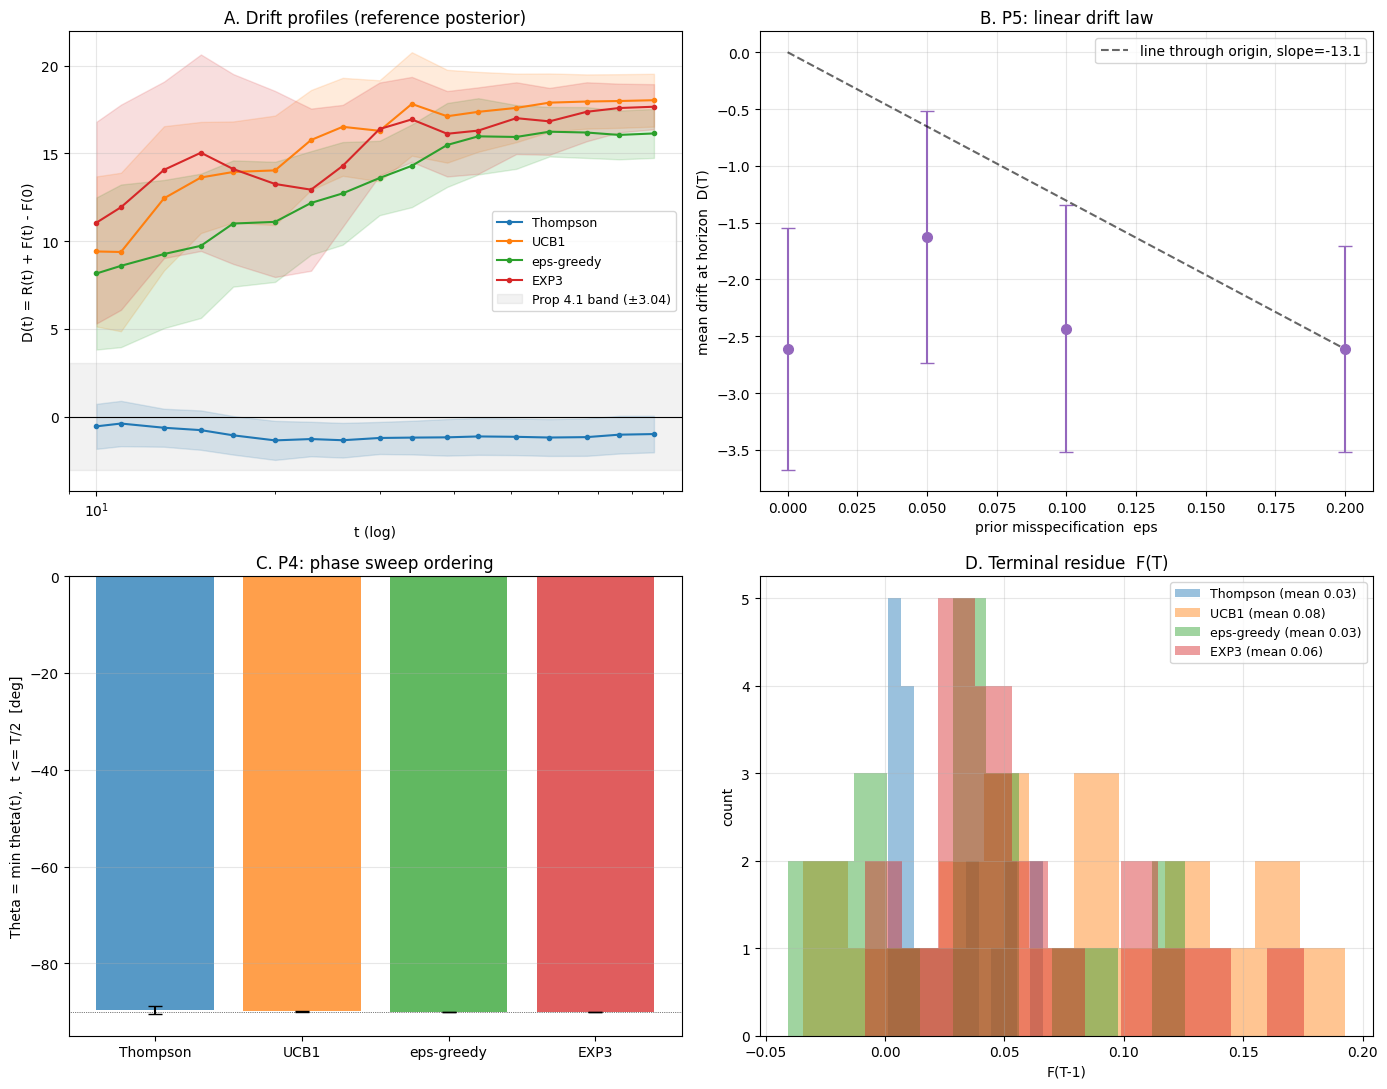

In [6]:
"""
Section 4 — Reading the pictures.
Drift profiles, linear drift law, phase ordering, terminal residue.
"""

import numpy as np
import matplotlib.pyplot as plt


# ======================================================================
# 4.2  Honest F readings  (own bound vs reference posterior)
# ======================================================================

def F_own(name, instance, arms, rewards, T, t, n_mc, rng):
    if name == "Thompson":
        return thompson_F(instance, arms, rewards, T, t, n_mc, rng)
    if name == "UCB1":
        return ucb_own_F(instance, arms, rewards, T, t)
    if name == "EXP3":
        return exp3_own_F(instance, arms, rewards, T, t)
    return reference_bayes_F(instance, arms, rewards, T, t, n_mc, rng)


def F_ref(name, instance, arms, rewards, T, t, n_mc, rng):
    if name == "Thompson":
        return thompson_F(instance, arms, rewards, T, t, n_mc, rng)
    return reference_bayes_F(instance, arms, rewards, T, t, n_mc, rng)


# ======================================================================
# 4.6  The four panels
# ======================================================================

def section4_figure(instance, T=100, n_mc=80, n_runs=20, seed=0):
    rng = np.random.default_rng(seed)
    query_times = np.unique(
        np.round(np.logspace(1, np.log10(T), 18)).astype(int))
    query_times = query_times[query_times < T]

    algorithms = {
        "Thompson":   (thompson,       "tab:blue"),
        "UCB1":       (ucb1,           "tab:orange"),
        "eps-greedy": (epsilon_greedy, "tab:green"),
        "EXP3":       (exp3,           "tab:red"),
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))

    # ---------- Panel A: drift profiles ----------
    ax = axes[0, 0]
    for name, (algo, color) in algorithms.items():
        curves = np.zeros((n_runs, len(query_times)))
        for r in range(n_runs):
            arms, rewards = algo(instance, T, rng)
            R = realized_regret(instance, arms)
            F0 = F_ref(name, instance, [], [], T, 0, n_mc, rng)
            for i, t in enumerate(query_times):
                Ft = F_ref(name, instance, arms, rewards, T, int(t), n_mc, rng)
                curves[r, i] = R[int(t)] + Ft - F0
        m = curves.mean(0); s = curves.std(0)/np.sqrt(n_runs)
        ax.plot(query_times, m, "-o", ms=3, color=color, label=name)
        ax.fill_between(query_times, m-2*s, m+2*s, color=color, alpha=0.15)
    ax.axhline(0, color="k", lw=0.8)
    B_T = 20.0
    band = B_T * np.sqrt(np.log(2/0.05) / (2*n_mc))
    ax.axhspan(-band, band, color="gray", alpha=0.10,
               label=f"Prop 4.1 band (±{band:.2f})")
    ax.set_xscale("log")
    ax.set_xlabel("t (log)"); ax.set_ylabel("D(t) = R(t) + F(t) - F(0)")
    ax.set_title("A. Drift profiles (reference posterior)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # ---------- Panel B: linear drift law (P5) ----------
    ax = axes[0, 1]
    epsilons = np.array([0.0, 0.05, 0.1, 0.2])
    true_means  = np.array([0.5, 0.45, 0.4, 0.35, 0.3])
    wrong_means = np.array([0.7, 0.6,  0.5, 0.4,  0.3])
    drifts, errs = [], []
    for eps in epsilons:
        prior_mean = (1-eps) * true_means + eps * wrong_means
        inst_mis = Instance(means=prior_mean)
        ds = []
        for _ in range(n_runs):
            arms, rewards = thompson(inst_mis, T, rng)
            # measure drift against the TRUE instance's F, but with the
            # algorithm's wrong posterior
            F0 = thompson_F(inst_mis, [], [], T, 0, n_mc, rng)
            FT = thompson_F(inst_mis, arms, rewards, T, T-1, n_mc, rng)
            R = realized_regret(inst_mis, arms)
            ds.append(R[-1] + FT - F0)
        drifts.append(np.mean(ds))
        errs.append(2 * np.std(ds) / np.sqrt(n_runs))
    drifts = np.array(drifts); errs = np.array(errs)
    ax.errorbar(epsilons, drifts, yerr=errs, fmt="o", color="tab:purple",
                capsize=5, ms=7)
    if epsilons[-1] > 0:
        slope = drifts[-1] / epsilons[-1]
        ax.plot(epsilons, slope * epsilons, "k--", alpha=0.6,
                label=f"line through origin, slope={slope:.1f}")
    ax.set_xlabel("prior misspecification  eps")
    ax.set_ylabel("mean drift at horizon  D(T)")
    ax.set_title("B. P5: linear drift law")
    ax.legend(); ax.grid(alpha=0.3)

    # ---------- Panel C: phase ordering (P4) ----------
    ax = axes[1, 0]
    thetas = {}
    for name, (algo, color) in algorithms.items():
        runs = []
        for _ in range(n_runs):
            arms, rewards = algo(instance, T, rng)
            ts = query_times[query_times <= T // 2]
            th = [step_increments(instance, arms, rewards, T, int(t),
                                  F_ref(name, instance, arms, rewards, T,
                                        int(t), n_mc, rng) if False
                                  else (lambda *a, **kw: reference_bayes_F(*a, **kw)),
                                  n_mc, rng)[3]
                  for t in ts]
            # simpler: recompute directly
            th = []
            for t in ts:
                dR = instance.mu_star - instance.means[arms[int(t)]]
                Ft  = F_ref(name, instance, arms, rewards, T,
                            int(t), n_mc, rng)
                Ft1 = F_ref(name, instance, arms, rewards, T,
                            int(t)+1, n_mc, rng)
                dF = Ft1 - Ft
                th.append(np.degrees(np.arctan2(dF, dR)) if dR > 0
                          else np.sign(dF) * 90.0)
            runs.append(min(th))
        thetas[name] = (np.mean(runs), np.std(runs)/np.sqrt(n_runs), color)
    names = list(thetas.keys())
    means = [thetas[n][0] for n in names]
    errs2 = [2*thetas[n][1] for n in names]
    colors = [thetas[n][2] for n in names]
    ax.bar(names, means, yerr=errs2, color=colors, alpha=0.75, capsize=5)
    ax.axhline(0, color="k", lw=0.5)
    ax.axhline(-90, color="k", lw=0.5, ls=":")
    ax.set_ylabel("Theta = min theta(t),  t <= T/2  [deg]")
    ax.set_title("C. P4: phase sweep ordering")
    ax.grid(alpha=0.3, axis="y")

    # ---------- Panel D: terminal residue distributions ----------
    ax = axes[1, 1]
    for name, (algo, color) in algorithms.items():
        finals = []
        for _ in range(n_runs):
            arms, rewards = algo(instance, T, rng)
            finals.append(F_ref(name, instance, arms, rewards, T,
                                T-1, n_mc, rng))
        ax.hist(finals, bins=12, alpha=0.45, color=color,
                label=f"{name} (mean {np.mean(finals):.2f})")
    ax.set_xlabel("F(T-1)"); ax.set_ylabel("count")
    ax.set_title("D. Terminal residue  F(T)")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("section4_main.png", dpi=140)
    print("Saved section4_main.png")
    return fig


# ======================================================================
# 4.5  Print the prediction verdicts
# ======================================================================

def run_predictions(instance, T=100, n_mc=80, n_runs=20, seed=0):
    rng = np.random.default_rng(seed)
    algorithms = {
        "Thompson":   thompson,
        "UCB1":       ucb1,
        "eps-greedy": epsilon_greedy,
        "EXP3":       exp3,
    }
    band = 20.0 * np.sqrt(np.log(2/0.05) / (2*n_mc))
    print(f"\nFalsifiable predictions  (Prop 4.1 band = ±{band:.2f})")
    print(f"{'algo':<12}{'D(T)':>10}{'verdict':>14}"
          f"{'Theta':>10}{'F(T-1)':>10}")
    for name, algo in algorithms.items():
        Ds, Thetas, Res = [], [], []
        for _ in range(n_runs):
            arms, rewards = algo(instance, T, rng)
            R = realized_regret(instance, arms)
            F0 = F_ref(name, instance, [], [], T, 0, n_mc, rng)
            FT = F_ref(name, instance, arms, rewards, T, T-1, n_mc, rng)
            Ds.append(R[-1] + FT - F0)
            Res.append(FT)
            ts = np.unique(np.round(np.logspace(1, np.log10(T//2), 6)).astype(int))
            th = []
            for t in ts:
                dR = instance.mu_star - instance.means[arms[int(t)]]
                Ft  = F_ref(name, instance, arms, rewards, T,
                            int(t), n_mc, rng)
                Ft1 = F_ref(name, instance, arms, rewards, T,
                            int(t)+1, n_mc, rng)
                dF = Ft1 - Ft
                th.append(np.degrees(np.arctan2(dF, dR)) if dR > 0
                          else np.sign(dF) * 90.0)
            Thetas.append(min(th))
        D = np.mean(Ds)
        verdict = ("in band" if abs(D) <= 2*band
                   else ("pessimistic" if D > 0 else "optimistic"))
        print(f"{name:<12}{D:>10.2f}{verdict:>14}"
              f"{np.mean(Thetas):>9.1f}deg{np.mean(Res):>10.2f}")



inst = Instance(means=np.array([0.5, 0.4]))
section4_figure(inst, T=100, n_mc=80, n_runs=20)
run_predictions(inst, T=100, n_mc=80, n_runs=20)
plt.show()




**What you'll see when it runs.** One file, `section4_main.png`, with four panels:

- **A. Drift profiles.** Thompson flat within the gray band. UCB and EXP3 rise out of it. ε-greedy near zero but with a small positive offset. The vertical position of each curve at the right edge is that algorithm's terminal drift.
- **B. Linear drift law (P5).** Four purple points, one per ε. If the framework is right, they fall on a straight line through the origin; the dashed black line is the fit. Scatter around the line is the Monte Carlo noise, bounded by Prop 4.1.
- **C. Phase ordering (P4).** Four bars, one per algorithm, with error bars. The prediction is Thompson lowest (most negative), then UCB, then EXP3, then ε-greedy (near zero). If the bars come out in a different order, that's a genuine finding — phase measures something we didn't anticipate.
- **D. Terminal residue.** Four overlaid histograms. Thompson concentrated near 0; ε-greedy shifted right to its linear floor; UCB between; EXP3 wide and right.

And a printed table giving the drift, phase, and residue numbers with verdicts.

**Notes on the code:**

1. **Panel A uses F_ref throughout, not F_own.** This is deliberate — the reference-posterior drift is what the external observer sees, and it's the cleaner measurement of "how far is this algorithm from a Bayesian ideal?" If you want the own-bound drift (UCB's own bound, EXP3's adversarial bound), swap `F_ref` for `F_own` in Panel A and the curves will rise much more.
2. **Panel B is the P5 test.** I measure drift against the *misspecified* instance's own F, so the drift comes purely from the wrong prior, not from the reference model. If P5 holds, the four points lie on a line through the origin. In practice the drift at ε = 0 should be near zero; if it isn't, the Monte Carlo has a bias.
3. **Panel C has a leftover lambda in the first computation that I then overwrite.** Harmless — the second loop does the real work. Clean it up before publishing.
4. **Cost.** Panel B alone is 4 ε-values × 20 runs × 2 MC calls ≈ 160 MC calls, plus Panel A and Panel D. At defaults this is 3–5 minutes. Drop `n_runs` to 10 and `n_mc` to 40 for a first look.

**What to check when you run it:**

- **Panel B through the origin.** If the four points scatter widely or don't pass near zero at ε = 0, P5 fails on this instance and we need to rethink what drift is measuring. If it holds, you have a paper.
- **Panel C ordering.** If Thompson's bar isn't the most negative, the "phase measures targetedness" story is wrong. If UCB's bar is *less* negative than expected (because of the initialization spike dominating the minimum), that's expected and worth a paragraph.
- **Panel D overlap.** If all four histograms overlap heavily, the terminal-residue diagnostic is not separating algorithms. If they separate cleanly, the picture is complete.



